# K-means Clustering

The analysis here uses `Sabi_subsample.dta`. This contains a random subsample of firms from *Sistema de Análisis de Balances Ibéricos* (SABI) (equivalent to Orbis/Amadeus for the Iberian peninsula).

The goal of this exercise is to implement **K-means clustering**, an *unsupervised machine learning* algorithm that groups observations based on shared characteristics or features. The algorithm partitions observations into a set number of `K` clusters by minimizing the distance (usually the Euclidean distance) between each point and the centroid of its assigned cluster. 

Note that the K-means algorithm is sensitive to the initial choice of cluster centers. Thus, one can run the algorithm multiple times with different initial guesses and choose the solution with the smallest objective function value. Most implementations, including that of *scikit-learn*, allow for this via the `n_init` parameter.

The scale of the data can also have an impact on the clustering results. Thus, it is often recommended to standardize the data before applying the K-means algorithm. 

In this exercise, we follow <span style="color:blue">De Haas et al. (2022)</span> and use k-means to uncover natural groupings within startups, based on financial and structural characteristics such as *leverage*, *liquidity*, *tangibility*, and *size (in terms of total assets and number of employees)*. 

Reference:
- De Haas, Ralph, Vincent Sterk and Neeltje Van Horen. (2022). "Start-up types and macroeconomic performance in Europe," Bank of England working papers 986, Bank of England.

## 1. Pre-processing steps

#### <span style="color:#1E90FF">Load basic packages</span>

In [195]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler

#### <span style="color:#1E90FF">Import and filter data</span>

Some additional data cleaning/handling steps:

1. Drop firms in the following sectors: Financial Services, Education, Health and Social Work, Membership Activities. The dummy variable `sector_exclude` tracks these sectors. These are relatively non-standard sectors.
2. Winsorize financial and real variables used in the analysis.

In [198]:
# Load the data
file_path = "/Users/andrealorensy/Desktop/Andrea's Files/CEMFI/Other data/Sabi_subsample.dta"  # Use your file path here
raw_data = pd.read_stata(file_path)

# Display basic information about the dataset
raw_data.head()

,year,firmID,estab_year,Equity,Working_capital,EBITDA,Tangible_FA,NACE_2digit,NACE_code,postal_code,...,Cash,ST_FinInv,Material_cost,Interest_expense,age,STdebt_tot,Total_debt,Liquidity,sector_exclude,public
0,2001,1000777,1942.0,3866570.02,3838623.340,338573.140,2223964.70,46,4674,48006.0,...,299504.529,1066.80,5873993.77,143604.44,59.0,1497653.125,2339070.000,3.005713e+05,NaN,Private
1,2002,1000777,1942.0,3992642.92,2724421.660,431992.329,2225407.42,46,4674,48006.0,...,277667.430,1066.80,6423704.75,152133.86,60.0,1359299.250,1960311.375,2.787342e+05,NaN,Private
2,2003,1000777,1942.0,4171305.21,2575553.309,484453.930,2207351.52,46,4674,48006.0,...,235875.629,6647.83,6719607.55,140704.08,61.0,1858195.375,2218802.750,2.425235e+05,NaN,Private
3,2004,1000777,1942.0,3278175.42,2403962.340,392795.560,841330.19,46,4674,48006.0,...,2815595.099,2554672.05,7056773.78,137269.01,62.0,1644016.125,2264218.500,5.370267e+06,NaN,Private
4,2005,1000777,1942.0,3544598.24,2016220.260,344851.550,562212.00,46,4674,48006.0,...,721661.200,455823.88,6579242.91,110178.98,63.0,1360340.375,1360340.375,1.177485e+06,NaN,Private


In [200]:
# Drop specific sectors
filtered_data = raw_data[raw_data['sector_exclude'] != 1]

#### <span style="color:#1E90FF">Construct financial/real variables for use</span>

In [203]:
# Copy data into new data frame
data_reg = filtered_data.copy()

# Basic ratio variables
data_reg['leverage']     = data_reg['Total_debt'] / data_reg['Assets'].replace(0, np.nan)
data_reg['liq_ratio']    = data_reg['Liquidity'] / data_reg['Assets'].replace(0, np.nan)
data_reg['tang_ratio']   = data_reg['Tangible_FA'] / data_reg['Assets'].replace(0, np.nan)

# Sort by firm and year
data_reg = data_reg.sort_values(by=['firmID', 'year']).reset_index(drop=True)

# Log transformations
data_reg['l_Assets']  = np.log(data_reg['Assets'].replace(0, np.nan))

In [205]:
# List all columns (variables)
print(data_reg.columns.tolist())

['year', 'firmID', 'estab_year', 'Equity', 'Working_capital', 'EBITDA', 'Tangible_FA', 'NACE_2digit', 'NACE_code', 'postal_code', 'revenue', 'Fixed_Assets', 'employees', 'Wages', 'Assets', 'Current_liab', 'LTdebt', 'Cash', 'ST_FinInv', 'Material_cost', 'Interest_expense', 'age', 'STdebt_tot', 'Total_debt', 'Liquidity', 'sector_exclude', 'public', 'leverage', 'liq_ratio', 'tang_ratio', 'l_Assets']


In [207]:
# Detailed info about data types and non-null counts
print(data_reg.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 898848 entries, 0 to 898847
Data columns (total 31 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   year              898848 non-null  int16   
 1   firmID            898848 non-null  int32   
 2   estab_year        898767 non-null  float64 
 3   Equity            898829 non-null  float64 
 4   Working_capital   890302 non-null  float64 
 5   EBITDA            898715 non-null  float64 
 6   Tangible_FA       872505 non-null  float64 
 7   NACE_2digit       898848 non-null  int8    
 8   NACE_code         898848 non-null  int16   
 9   postal_code       898580 non-null  float64 
 10  revenue           898848 non-null  float64 
 11  Fixed_Assets      898848 non-null  float64 
 12  employees         898848 non-null  int32   
 13  Wages             870765 non-null  float64 
 14  Assets            898848 non-null  float64 
 15  Current_liab      898718 non-null  float64 
 16  LT

In [209]:
# Subset of variables for K-means clustering
data_kmm = data_reg[['firmID', 'year', 'NACE_2digit', 'NACE_code', 'age', 'estab_year',
                     'leverage', 'liq_ratio', 'tang_ratio', 'employees','l_Assets']]
vars_to_treat = ['leverage', 'liq_ratio', 'tang_ratio', 'employees', 'l_Assets']

data_kmm_clean = data_kmm.dropna(subset=vars_to_treat).copy()

# Keep startups only
data_kmm_clean = data_kmm_clean[data_kmm_clean['year'] == data_kmm_clean['estab_year']]

In [211]:
# Winsorize variables to be used for regressions
def winsorize_series_inplace(s, lower_percentile=0.01, upper_percentile=0.99):
    lower = s.quantile(lower_percentile)
    upper = s.quantile(upper_percentile)
    
    # Replace values less than lower with lower, and values greater than upper with upper
    # This "clips" the series between the lower and upper bounds
    return s.clip(lower, upper)

for var in vars_to_treat:
    # Replace the original column in data_reg with its winsorized version
    data_kmm_clean[var] = winsorize_series_inplace(data_kmm_clean[var])

In [213]:
# Descriptive statistics on variables
data_kmm_clean[vars_to_treat].describe().round(4).T

,count,mean,std,min,25%,50%,75%,max
leverage,18490.0,0.1741,0.2729,0.0000,0.0000,0.0000,0.2893,1.0396
liq_ratio,18490.0,0.2428,0.2375,0.0009,0.0568,0.1635,0.3584,0.9680
tang_ratio,18490.0,0.2371,0.2469,0.0000,0.0275,0.1463,0.3884,0.9083
employees,18490.0,3.2512,5.5967,0.0000,0.0000,2.0000,4.0000,39.0000
l_Assets,18490.0,11.5203,1.3614,8.3653,10.6294,11.4639,12.3389,15.6997


In [215]:
# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_kmm_clean[vars_to_treat])
X_scaled_df = pd.DataFrame(X_scaled, columns=vars_to_treat, index=data_kmm_clean.index)

In [217]:
# Descriptive statistics on variables (to check if standardization was done correctly)
X_scaled_df.describe().round(4).T

# Note: Since these are standardized variables, it should not be surprising to see negative values on financial ratios and number of employees!

,count,mean,std,min,25%,50%,75%,max
leverage,18490.0,0.0,1.0,-0.6378,-0.6378,-0.6378,0.4224,3.1716
liq_ratio,18490.0,-0.0,1.0,-1.0182,-0.7832,-0.3337,0.4867,3.0531
tang_ratio,18490.0,-0.0,1.0,-0.9604,-0.8492,-0.3679,0.6125,2.7182
employees,18490.0,0.0,1.0,-0.5809,-0.5809,-0.2236,0.1338,6.3876
l_Assets,18490.0,-0.0,1.0,-2.3175,-0.6544,-0.0414,0.6013,3.0700


<br>

## 2. K-means clustering

### 2.1 Implementing K-means clustering

In [219]:
## Import kmeans 
from sklearn.cluster import KMeans

n_clusters=5
kmeans5 = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit(X_scaled_df)

In [221]:
kmeans5.cluster_centers_

array([[-0.04396846, -0.15850707, -0.18651101,  4.25956364,  1.51264713],
       [-0.43966443,  1.54135356, -0.54115662, -0.2273247 , -0.64673023],
       [ 1.82132278, -0.41803497,  0.63334436, -0.13560051,  0.37609172],
       [-0.37925308, -0.44278721,  1.29770131, -0.18041727, -0.25514238],
       [-0.39817475, -0.40568774, -0.57073356, -0.11765975,  0.15369792]])

In [223]:
# Unscale the data
X_unscaled = pd.DataFrame(
    scaler.inverse_transform(X_scaled_df[vars_to_treat]),
    columns=vars_to_treat,
    index=X_scaled_df.index
)
X_unscaled['cluster'] = kmeans5.labels_

### 2.2 Descriptive Statistics on the clusters

In [226]:
# Add cluster labels to original data
data_kmm_clean['cluster'] = kmeans5.labels_

# Mean values of each variable by cluster
cluster_profiles = data_kmm_clean.groupby('cluster')[vars_to_treat].mean().round(2)
print('------------ Mean ------------')
print(cluster_profiles)

# Count observations per cluster
cluster_counts = data_kmm_clean['cluster'].value_counts().sort_index()

# Compute share
cluster_share = cluster_counts / cluster_counts.sum()

# Combine into a DataFrame
cluster_summary = pd.DataFrame({
    'count': cluster_counts,
    'share': cluster_share
})

# Format share as percentage (4 decimals)
cluster_summary['share'] = cluster_summary['share'].round(4)

# Display
print('\n------------ Number of Observations and Share per Cluster ------------')
print(cluster_summary)


------------ Mean ------------
         leverage  liq_ratio  tang_ratio  employees  l_Assets
cluster                                                      
0            0.16       0.21        0.19      27.11     13.58
1            0.05       0.61        0.10       1.98     10.64
2            0.67       0.14        0.39       2.49     12.03
3            0.07       0.14        0.56       2.24     11.18
4            0.07       0.15        0.10       2.59     11.73

------------ Number of Observations and Share per Cluster ------------
         count   share
cluster               
0          654  0.0354
1         3862  0.2089
2         3255  0.1760
3         3353  0.1813
4         7366  0.3984


<span style="color:red">
The result suggests that the 5 clusters can be described using the firm-level indicators used in the clustering procedure.

- Cluster 0: large in terms of total number of employees and balance sheet size (total assets)
- Cluster 1: high share of liquid assets in total assets
- Cluster 2: high leverage
- Cluster 3: high tangibility
- Cluster 4: does not stand out in any way, "basic"
</span>

In [228]:
# Rename cluster labels after observing summary stats on clusters
data_kmm_clean['cluster_named'] = data_kmm_clean['cluster'].map({
    0: 'Large',
    1: 'Cash-intensive',
    2: 'High leverage',
    3: 'K-intensive',
    4: 'Basic',
})

X_unscaled['cluster_named'] = X_unscaled['cluster'].map({
    0: 'Large',
    1: 'Cash-intensive',
    2: 'High leverage',
    3: 'K-intensive',
    4: 'Basic',
})

#### **Plot distribution of variables across clusters**

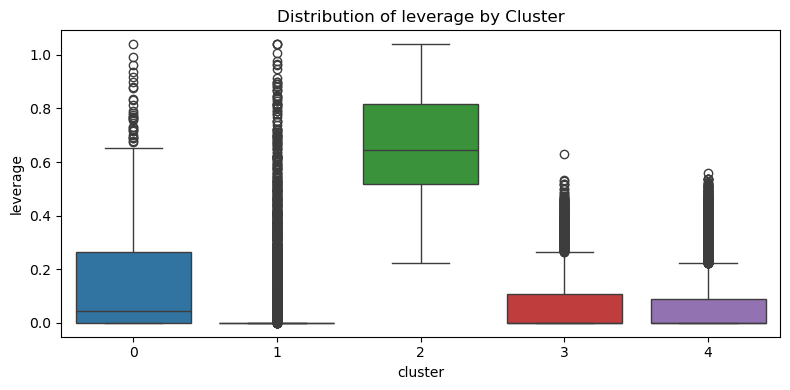

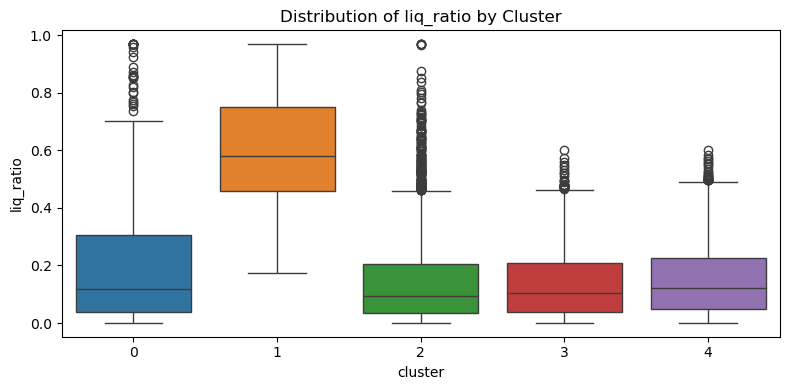

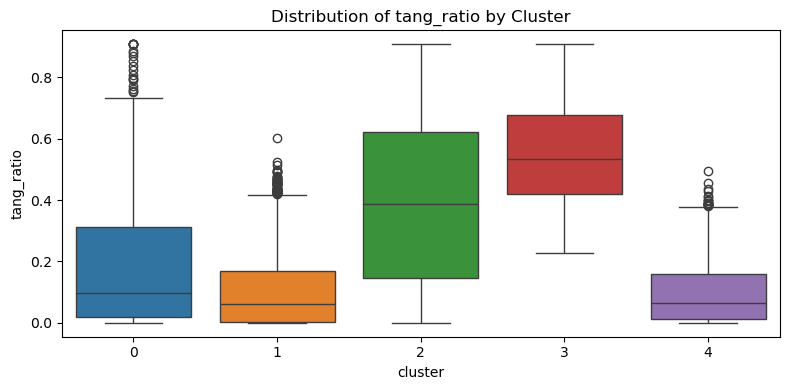

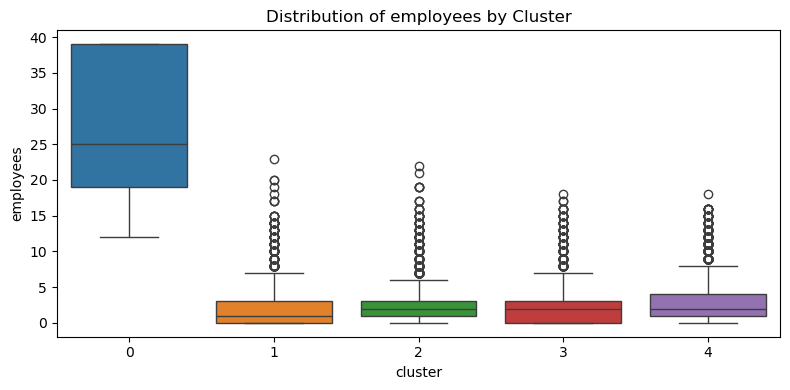

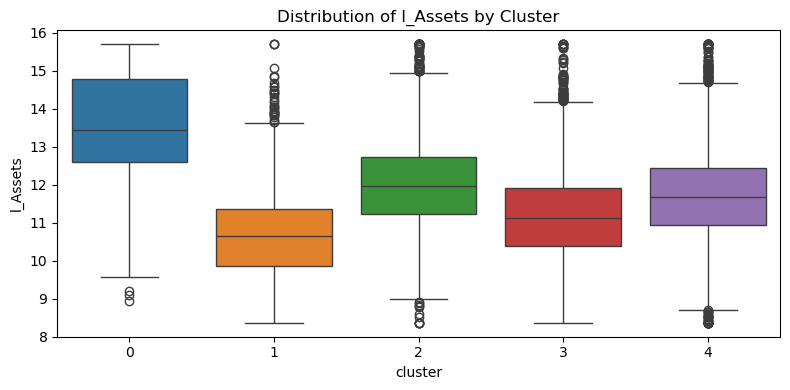

In [231]:
# Plot distribution of variables across clusters
import seaborn as sns

for var in vars_to_treat:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=data_kmm_clean, x='cluster', y=var, hue='cluster', palette='tab10', legend=False)
    plt.title(f'Distribution of {var} by Cluster')
    plt.tight_layout()
    plt.show()


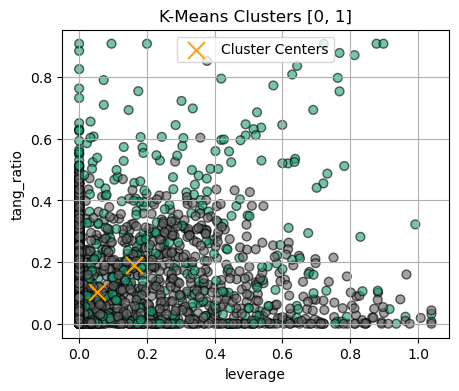

In [233]:
# Choose clusters to plot
clusters_to_plot = [0, 1]

# Filter the data
X_filtered = X_unscaled[X_unscaled['cluster'].isin(clusters_to_plot)]

# Get unscaled cluster centers as DataFrame
cluster_centers_df = pd.DataFrame(
    scaler.inverse_transform(kmeans4.cluster_centers_),
    columns=vars_to_treat
)
cluster_centers_df['cluster'] = range(n_clusters)
cluster_centers_filtered = cluster_centers_df[cluster_centers_df['cluster'].isin(clusters_to_plot)]

# Plot
x_var = vars_to_treat[0]  # 'leverage'
y_var = vars_to_treat[2]  # 'tang_ratio'

fig, ax = plt.subplots(figsize=(5, 4))

# Data points
ax.scatter(
    X_filtered[x_var],
    X_filtered[y_var],
    c=X_filtered['cluster'],
    cmap='Dark2',
    alpha=0.6,
    edgecolor='k',
    s=40
)

# Cluster centers
ax.scatter(
    cluster_centers_filtered[x_var],
    cluster_centers_filtered[y_var],
    c='orange',
    marker='x',
    s=150,
    label='Cluster Centers'
)

ax.set_xlabel(x_var)
ax.set_ylabel(y_var)
ax.set_title(f'K-Means Clusters {clusters_to_plot}')
ax.legend()
plt.grid(True)
plt.show()


#### **Visualize clusters in multiple dimensions**

/Users/andrealorensy/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


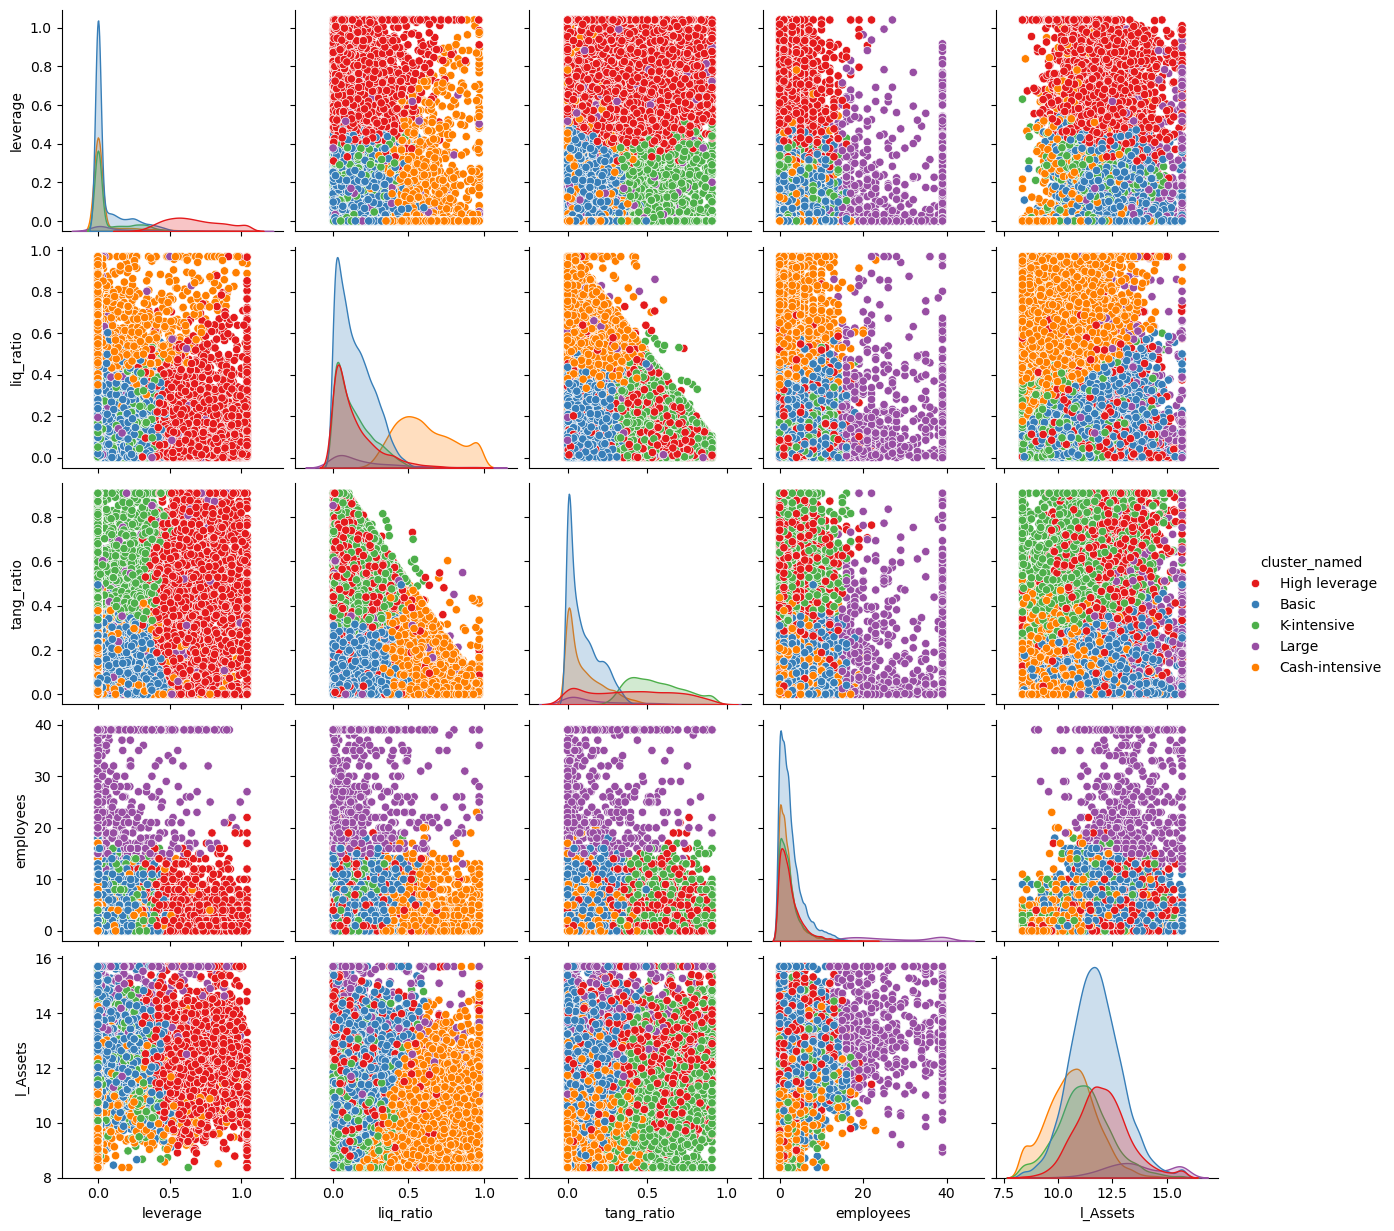

In [267]:
import seaborn as sns

sns.pairplot(X_unscaled[vars_to_treat + ['cluster_named']], hue='cluster_named', palette='Set1')


<br>

#### **Check cluster center distances**

- compute the **cosine similarity** between cluster centers.

**Cosine similarity** measures the angle between two vectors in a multi-dimensional space.
- It tells you how similar the direction of two vectors is.
- It ignores magnitude (length) and focuses purely on orientation.

For two vectors **A** and **B**, the cosine similarity is: 
$$ \text{cosine\_similarity} = \frac{A \cdot B}{||A|| \cdot ||B||} $$
 
- $A \cdot B$ = dot product of vectors
- ||A|| and ||B|| = Euclidean norms

The cosine similarity always belongs to the interval $[−1,+1]$. For example, two proportional vectors have a cosine similarity of +1, two orthogonal vectors have a similarity of 0, and two opposite vectors have a similarity of −1.

In [235]:
from sklearn.metrics.pairwise import cosine_similarity

# Cosine similarity between scaled cluster centers
cos_sim_matrix = cosine_similarity(kmeans4.cluster_centers_)

# Convert to DataFrame for readability
cos_sim_df = pd.DataFrame(cos_sim_matrix, index=range(n_clusters), columns=range(n_clusters))
print("Cosine Similarity Between Cluster Centers:")
print(cos_sim_df.round(3))


Cosine Similarity Between Cluster Centers:
       0      1      2      3      4
0  1.000 -0.251 -0.015 -0.199 -0.021
1 -0.251  1.000 -0.544 -0.381 -0.142
2 -0.015 -0.544  1.000  0.083 -0.506
3 -0.199 -0.381  0.083  1.000 -0.355
4 -0.021 -0.142 -0.506 -0.355  1.000


- Cluster 1 vs. 2 = -0.544: strongly opposite directions
- Cluster 0 vs. 2 = -0.015: almost orthogonal (no similarity)
- Cluster 0 vs. 3 = -0.199: mild dissimilarity

Note that if we compute the **Euclidean distance**, we will find that Cluster 0 (large) is far from all the other clusters. And, it is as if Clusters 0, 1, and 3 are not that different in the feature space (shown below). Yet if we look at the summary statistics of each cluster, clearly, there are economic differences. 

- Cluster 0 (large) firms are substantially larger in terms of `employees` and `l_Assets`. That it's so far in the Euclidean space is likely due to these scale-heavy features.

In [238]:
# Euclidean distance among cluster centers
from scipy.spatial.distance import pdist, squareform

# Get unscaled cluster centers
centers_unscaled = scaler.inverse_transform(kmeans4.cluster_centers_)

# Pairwise distances between centers
distances = pdist(centers_unscaled)  # condensed form
distance_matrix = squareform(distances)  # square matrix

print(pd.DataFrame(distance_matrix))

           0          1          2          3          4
0   0.000000  25.286188  24.652535  24.967793  24.567549
1  25.286188   0.000000   1.698184   0.884108   1.333475
2  24.652535   1.698184   0.000000   1.090396   0.746331
3  24.967793   0.884108   1.090396   0.000000   0.803795
4  24.567549   1.333475   0.746331   0.803795   0.000000


<br>

#### **Summary Statistics of Clusters**

In [241]:
data_kmm_clean.head()

,firmID,year,NACE_2digit,NACE_code,age,estab_year,leverage,liq_ratio,tang_ratio,employees,l_Assets,cluster,cluster_named
2546,1194299,2000,47,4719,0.0,2000.0,0.657836,0.097097,0.325513,0,12.887145,2,High leverage
3622,1295864,2000,43,4321,0.0,2000.0,0.507078,0.055184,0.561190,4,12.419608,2,High leverage
3634,1297795,2000,41,4120,0.0,2000.0,0.062420,0.208246,0.028021,0,12.556914,4,Basic
3655,1298173,2000,70,7022,0.0,2000.0,0.000000,0.166034,0.008251,0,11.016586,4,Basic
3662,1298868,2000,41,4120,0.0,2000.0,0.000000,0.138124,0.763400,8,10.497468,3,K-intensive


In [243]:
cluster_labels = {
    0: 'Large',
    1: 'Cash-intensive',
    2: 'High leverage',
    3: 'K-intensive',
    4: 'Basic',
}

# Counts and shares
cluster_summary['label'] = cluster_summary.index.map(cluster_labels)
cluster_summary = cluster_summary.set_index('label')

# Mean values of each variable by cluster
cluster_profiles['label'] = cluster_profiles.index.map(cluster_labels)

# Set 'label' as the new index and drop the old numeric index
cluster_profiles = cluster_profiles.set_index('label')

# Combined display
combined = cluster_summary.join(cluster_profiles, how='inner')
print('\n------------ Combined Cluster Summary and Profiles ------------')
print(combined)



------------ Combined Cluster Summary and Profiles ------------
                count   share  leverage  liq_ratio  tang_ratio  employees  \
label                                                                       
Large             654  0.0354      0.16       0.21        0.19      27.11   
Cash-intensive   3862  0.2089      0.05       0.61        0.10       1.98   
High leverage    3255  0.1760      0.67       0.14        0.39       2.49   
K-intensive      3353  0.1813      0.07       0.14        0.56       2.24   
Basic            7366  0.3984      0.07       0.15        0.10       2.59   

                l_Assets  
label                     
Large              13.58  
Cash-intensive     10.64  
High leverage      12.03  
K-intensive        11.18  
Basic              11.73  


<span style="color:red">
To summarize, the analysis uncovers 5 types of startups in Spain:

- **Large**: large in terms of total number of employees and balance sheet size (total assets)
- **Cash-intensive**: high share of liquid assets in total assets
- **High leverage**: high leverage
- **K-intensive**: high leverage and high tangible share in total assets
- **Basic**: does not stand out in any way

**Basic** startups are most common, comprising approx. 40% of total startups. This is followed by the **cash-intensive**, **K-intensive** and **high leverage** startups, which are 20.9%, 18.1% and 17.6% of total startups respectively. Finally, the least common type of startup are the **large** startups, which have substantially more employees and total assets at incorporation. 

Note that in this analysis using a subsample of Spanish firms (firm-level data), the level of leverage in **high leverage** firms do not seem to go beyond a ratio of 1, while in De Haas et al. (2022), it does. **High leverage** firms in De Haas et al. (2022) clearly capture firms that are very leveraged and at risk. This may be due to differences in the data used for analysis, for example:
- *CompNet* uses *micro-aggregated* data, not *firm-level* data.
- *SABI* does not have complete coverage of the self-employed firms (i.e. zero-employment firms).
</span>

<br>

### 2.3 Assessing the optimal number of clusters

Here, we use the **Elbow method** and **Silhouette method** to determine the optimum number of clusters.

#### 2.3.1 Elbow Method

**Goal**: To choose the optimal number of clusters (`k`) in K-Means by looking at how the model’s performance improves with more clusters.

- Inertia = sum of squared distances between each point and its nearest cluster center.
- As you increase `k`, inertia decreases (clusters fit the data better).

The idea is that, initially, adding clusters dramatically reduces inertia. But at some point, adding more clusters yields diminishing returns. The “elbow” in the plot (a sharp bend) marks the ideal balance between:
- Model simplicity (fewer clusters)
- Fit (lower inertia)

In [247]:
# Implementing the elbow method
# Note: inertia is the sum of squared distances to the nearest cluster center
inertias = [KMeans(n_clusters=n, n_init=10, random_state=42).fit(X_scaled_df).inertia_ for n in range(1, 11)]

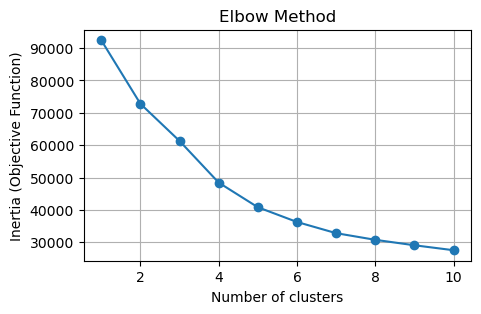

In [248]:
# Plot the inertia
fig, ax = plt.subplots(figsize=(5, 3))  # Set the figure size here
ax.plot(range(1, 11), inertias, marker='o')
ax.set(xlabel='Number of clusters', ylabel='Inertia (Objective Function)')
ax.set_title('Elbow Method')
ax.grid(True)

plt.show()

<br>

#### 2.3.2 Silhouette Method

**Goal**: Evaluate how well your data is clustered — do the clusters make sense?

**Silhouette Score** for each point:

$$
s = \frac{b - a}{\max(a, b)}
$$

- `a` = average distance to points within the same cluster
- `b` = average distance to points in the nearest neighboring cluster

A high average silhouette score suggests that clusters are tight and well-separated. The idea is to compute the average silhouette score for each value of `k` and choose the one with the highest score.

In [251]:
from sklearn.metrics import silhouette_score

sil_scores = []
for n in range(2, 11):
    kmeans = KMeans(n_clusters=n, n_init=10, random_state=42).fit(X_scaled_df)
    sil_scores.append(silhouette_score(X_scaled_df, kmeans.labels_))

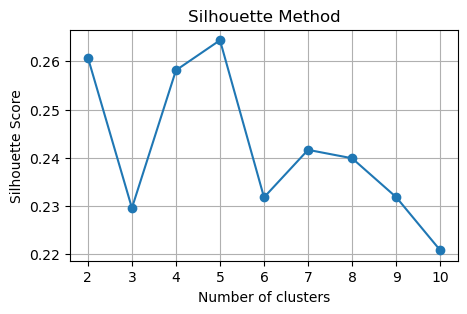

In [252]:
# Plot silhouette score
plt.figure(figsize=(5, 3))
plt.plot(range(2, 11), sil_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.grid(True)
plt.show()

#### 2.3.3 Additional diagnostics

1. Calinski–Harabasz Index (CH Index)
    - Measures how well-separated and compact the clusters are.
    - Formula:
        $$ CH(k) = \frac{\text{Between-cluster variance}}{\text{Within-cluster variance}} \cdot \frac{n-k}{k-1}$$
    - where $n$ = number of samples; $k$ = number of clusters
    - Higher CH score = better clustering
    - Points in each cluster are close to each other (low within-cluster dispersion)
    - Clusters are far apart (high between-cluster dispersion)
<br> <br>

2. Davies–Bouldin Index (DB Index)
    - Measures similarity between clusters — lower is better.
    - Formula:
        $$ \text{DB} = \frac{1}{k} \sum_{i=1}^{k} \max_{j \ne i} \left( \frac{S_i + S_j}{M_{ij}} \right)$$
    - where:
      - $S_i = \frac{1}{|C_i|} \sum_{x \in C_i} \|x - c_i\|$ is the average distance between each point in cluster $i$ and the centroid of cluster $i$ (intra-cluster scatter)
      - $M_{ij} = \|c_i - c_j\|$ is the distance between cluster centroids $i$ and $j$
    - Lower values mean:
        - Clusters are compact
        - Clusters are well-separated from each other

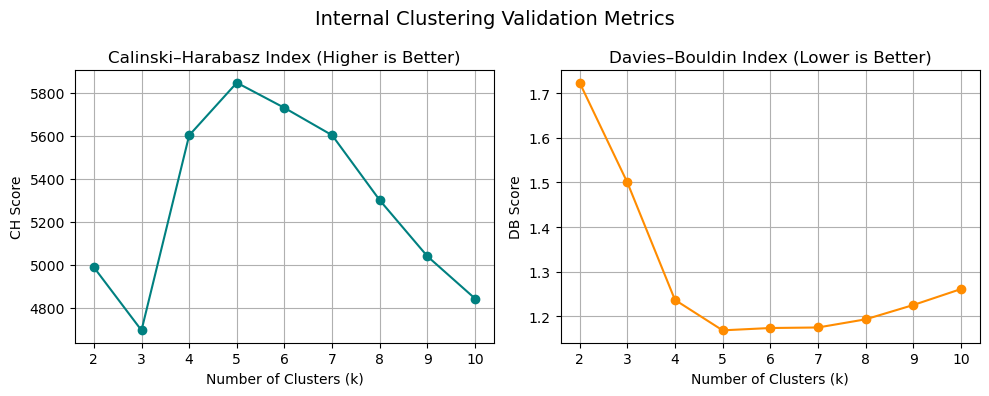

In [265]:
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt

# Range of cluster counts to test
k_range = range(2, 11)

# Store scores
ch_scores = []
db_scores = []

# Run KMeans for each k and compute metrics
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled_df)
    labels = kmeans.labels_
    
    ch = calinski_harabasz_score(X_scaled_df, labels)
    db = davies_bouldin_score(X_scaled_df, labels)
    
    ch_scores.append(ch)
    db_scores.append(db)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Calinski–Harabasz
ax[0].plot(k_range, ch_scores, marker='o', color='teal')
ax[0].set_title("Calinski–Harabasz Index (Higher is Better)")
ax[0].set_xlabel("Number of Clusters (k)")
ax[0].set_ylabel("CH Score")
ax[0].grid(True)

# Davies–Bouldin
ax[1].plot(k_range, db_scores, marker='o', color='darkorange')
ax[1].set_title("Davies–Bouldin Index (Lower is Better)")
ax[1].set_xlabel("Number of Clusters (k)")
ax[1].set_ylabel("DB Score")
ax[1].grid(True)

plt.suptitle("Internal Clustering Validation Metrics", fontsize=14)
plt.tight_layout()
plt.show()


#### 2.3.4 Summary

- Elbow method seems to suggest that $k = 4$ clusters is likely the elbow point — the place where adding more clusters gives diminishing returns.
- 5 or 6 clusters might technically improve the fit (lower inertia), but not meaningfully enough to justify the extra complexity.
<!-- With $k = 4$ clusters, each cluster has a clear interpretation.-->

- Silhouette method suggests that $k = 5$ clusters is optimal.
<!-- Yet, for $k = 5$ clusters (analysis not shown here), it is hard to pin down an exact description of one of the clusters (somewhat large, but not as big as the "large" startups in terms of `l_Assets` and `employees`).-->

- Other clustering evaluation metrics suggest that $k = 5$ clusters is optimal.